In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df=pd.read_csv("BuyLaptopDataset.csv")
df.head()

,Age,Income,Experience,BuyLaptop
0,22,30000,1,0
1,24,32000,1,0
2,25,35000,2,0
3,26,37000,2,0
4,27,39000,3,0


In [3]:
len(df)

40

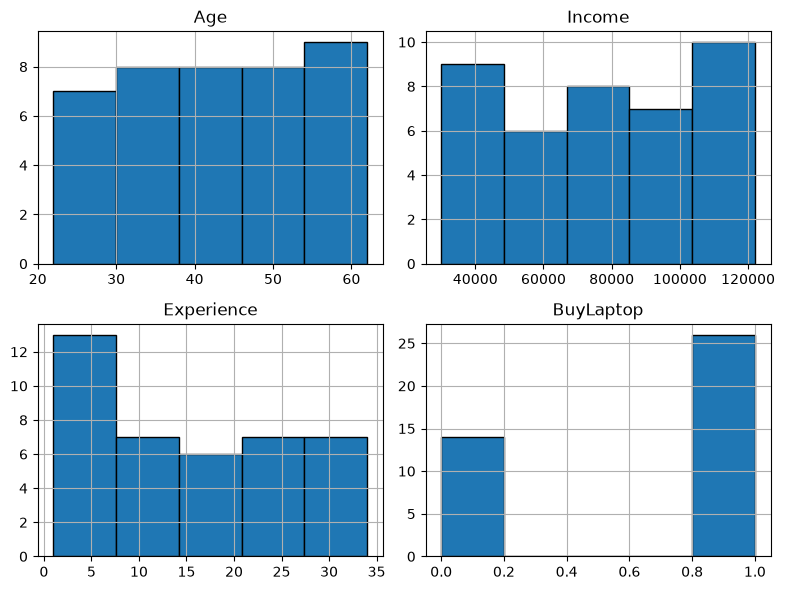

In [5]:
df.hist(figsize=(8,6),bins=5,edgecolor="black")
plt.tight_layout()
plt.show()

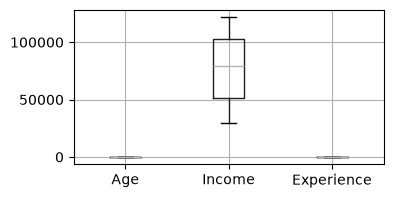

In [8]:
df[['Age','Income','Experience']].boxplot(figsize=(4,2))
plt.show()

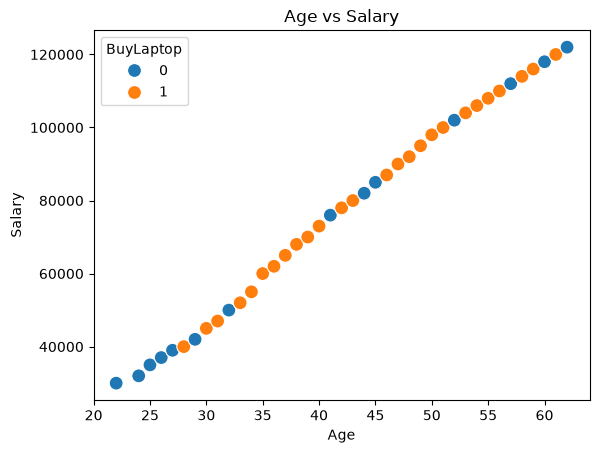

In [9]:
import seaborn as sns
sns.scatterplot(data=df,x='Age',y='Income',hue='BuyLaptop',s=100) #s=100 market size
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

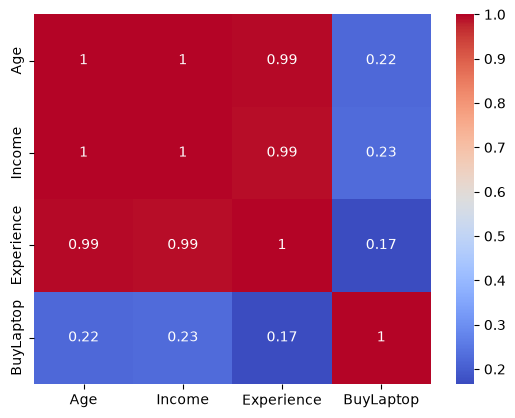

In [13]:
plt.figsize=(4,2)
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [15]:
X=df[['Age','Income','Experience']]
y=df['BuyLaptop']
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [45]:
rf=RandomForestClassifier(
    n_estimators=5,
    max_samples=0.80,
    bootstrap=True,
    random_state=42
)
#mean 5 decision trees will be created
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.8
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of th

In [46]:
y_pred=rf.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [47]:
acc=accuracy_score(y_test,y_pred)
acc

0.5

In [48]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.55      0.86      0.67         7

    accuracy                           0.50        12
   macro avg       0.27      0.43      0.33        12
weighted avg       0.32      0.50      0.39        12



In [49]:
new_customer=pd.DataFrame({
    "Age":[32],
    "Income":[55000],
    "Experience":[6]
})
new_pred=rf.predict(new_customer)
new_pred
if new_pred==1:
    print("Customer will buy laptop")
else:
    print("Customer will not buy laptop")

Customer will buy laptop


In [50]:
prob=rf.predict_proba(new_customer)
prob

array([[0., 1.]])

In [51]:
print(df.sample(n=len(df),replace=True,random_state=1))

    Age  Income  Experience  BuyLaptop
37   60  118000          32          0
12   35   60000           7          1
8    31   47000           5          1
9    32   50000           6          0
11   34   55000           7          1
5    28   40000           3          1
15   38   68000          10          1
0    22   30000           1          0
16   39   70000          11          1
1    24   32000           1          0
12   35   60000           7          1
7    30   45000           5          1
6    29   42000           4          0
25   48   92000          20          1
20   43   80000          15          1
37   60  118000          32          0
18   41   76000          13          0
20   43   80000          15          1
11   34   55000           7          1
28   51  100000          23          1
29   52  102000          24          0
14   37   65000           9          1
4    27   39000           3          0
23   46   87000          18          1
23   46   87000          